In [9]:
import os
import pandas as pd
import glob

# Get the current working directory (where the notebook is located)
root_directory = os.getcwd()

# Use glob to get a list of CSV files in the current directory
csv_files = glob.glob(os.path.join(root_directory, '*.csv'))

# Convert CSV files to Excel files
for csv_file in csv_files:
    excel_file = os.path.splitext(csv_file)[0] + '.xlsx'
    df = pd.read_csv(csv_file)  # Read CSV file into a pandas DataFrame
    df.to_excel(excel_file, index=False)  # Convert DataFrame to Excel file

    print(f'Converted {csv_file} to {excel_file}')

# Use glob to get a list of Excel files in the current directory
excel_files = glob.glob(os.path.join(root_directory, '*.xlsx'))

# Read Excel files into pandas DataFrames and store them in a dictionary
dataframes = {}
for csv_file in csv_files:
    file_name = os.path.basename(csv_file)
    df = pd.read_csv(csv_file)  # Read Excel file into a pandas DataFrame
    dataframes[file_name] = df  # Store the DataFrame in the dictionary with file name as key


Converted /Users/latherialcalbert/Desktop/Bachelor Essay Research copy 2/hexoskin/e/10-30-23-Hons-world-Poli-Eli.csv to /Users/latherialcalbert/Desktop/Bachelor Essay Research copy 2/hexoskin/e/10-30-23-Hons-world-Poli-Eli.xlsx
Converted /Users/latherialcalbert/Desktop/Bachelor Essay Research copy 2/hexoskin/e/10-18-23-Hons-world-Poli-Eli.csv to /Users/latherialcalbert/Desktop/Bachelor Essay Research copy 2/hexoskin/e/10-18-23-Hons-world-Poli-Eli.xlsx
Converted /Users/latherialcalbert/Desktop/Bachelor Essay Research copy 2/hexoskin/e/10-23-23-Hons-world-Poli-Eli.csv to /Users/latherialcalbert/Desktop/Bachelor Essay Research copy 2/hexoskin/e/10-23-23-Hons-world-Poli-Eli.xlsx
Converted /Users/latherialcalbert/Desktop/Bachelor Essay Research copy 2/hexoskin/e/10-25-23-Hons-world-Poli-Eli.csv to /Users/latherialcalbert/Desktop/Bachelor Essay Research copy 2/hexoskin/e/10-25-23-Hons-world-Poli-Eli.xlsx


In [10]:
# Iterate through the dictionary, delete specified columns, and print updated columns
for file_name, df in dataframes.items():
    print(f'Columns of DataFrame from {file_name} before deletion:')
    print(df.columns)  # Print columns before deletion
    
    # Delete the last column if DataFrame has more than one column
    if 'cadence [spm](/api/datatype/53/)' in df.columns:
        df.drop(columns=['cadence [spm](/api/datatype/53/)'], inplace=True)
    
    # Delete the "sleep position" column if it exists
    if 'sleep_position [NA](/api/datatype/270/)' in df.columns:
        df.drop(columns=['sleep_position [NA](/api/datatype/270/)'], inplace=True)
    
    # Update the DataFrame in the dictionary
    dataframes[file_name] = df
    
    print(f'Columns of DataFrame from {file_name} after deletion:')
    print(df.columns)  # Print columns after deletion
    print()  # Print an empty line for separation


Columns of DataFrame from 10-30-23-Hons-world-Poli-Eli.csv before deletion:
Index(['time [s/256]', 'breathing_rate [rpm](/api/datatype/33/)',
       'minute_ventilation [mL/min](/api/datatype/36/)',
       'minute_ventilation_adjusted [mL/min](/api/datatype/38/)',
       'sleep_position [NA](/api/datatype/270/)',
       'activity [g](/api/datatype/49/)',
       'heart_rate [bpm](/api/datatype/19/)',
       'cadence [spm](/api/datatype/53/)'],
      dtype='object')
Columns of DataFrame from 10-30-23-Hons-world-Poli-Eli.csv after deletion:
Index(['time [s/256]', 'breathing_rate [rpm](/api/datatype/33/)',
       'minute_ventilation [mL/min](/api/datatype/36/)',
       'minute_ventilation_adjusted [mL/min](/api/datatype/38/)',
       'activity [g](/api/datatype/49/)',
       'heart_rate [bpm](/api/datatype/19/)'],
      dtype='object')

Columns of DataFrame from 10-18-23-Hons-world-Poli-Eli.csv before deletion:
Index(['time [s/256]', 'breathing_rate [rpm](/api/datatype/33/)',
       'minut

In [11]:
for file_name, df in dataframes.items():
    print(df.shape)

(3006, 6)
(3208, 6)
(2721, 6)
(3268, 6)


In [12]:
nan_counts = {}

# Iterate through the dictionary and count NaN values for each DataFrame
for file_name, df in dataframes.items():
    nan_counts[file_name] = df.isna().sum().sum()

# Print the counts of NaN values for each DataFrame
for file_name, count in nan_counts.items():
    print(f'Number of NaN values in DataFrame from {file_name}: {count}')

Number of NaN values in DataFrame from 10-30-23-Hons-world-Poli-Eli.csv: 5
Number of NaN values in DataFrame from 10-18-23-Hons-world-Poli-Eli.csv: 5
Number of NaN values in DataFrame from 10-23-23-Hons-world-Poli-Eli.csv: 5
Number of NaN values in DataFrame from 10-25-23-Hons-world-Poli-Eli.csv: 5


In [13]:
for file_name, df in dataframes.items():
    df.dropna(inplace=True)
    print(df.shape)

(3004, 6)
(3206, 6)
(2719, 6)
(3266, 6)


In [14]:
nan_counts = {}

# Iterate through the dictionary and count NaN values for each DataFrame
for file_name, df in dataframes.items():
    nan_counts[file_name] = df.isna().sum().sum()

# Print the counts of NaN values for each DataFrame
for file_name, count in nan_counts.items():
    print(f'Number of NaN values in DataFrame from {file_name}: {count}')

Number of NaN values in DataFrame from 10-30-23-Hons-world-Poli-Eli.csv: 0
Number of NaN values in DataFrame from 10-18-23-Hons-world-Poli-Eli.csv: 0
Number of NaN values in DataFrame from 10-23-23-Hons-world-Poli-Eli.csv: 0
Number of NaN values in DataFrame from 10-25-23-Hons-world-Poli-Eli.csv: 0


In [15]:
import re

# Dates and corresponding stress scores
stress_scores = {
    '10-18-23': 0,
    '10-23-23': 0,
    '10-25-23': 1,
    '10-30-23': 1
}

# Extract dates from DataFrame titles and sort them chronologically
sorted_dates = sorted(dataframes.keys(), key=lambda x: pd.to_datetime(re.search(r'(\d{2}-\d{2}-\d{2})', x).group(), format='%m-%d-%y'))

# Loop through sorted dates and add a new column with corresponding stress scores
for date in sorted_dates:
    # Extract the date from the filename
    extracted_date = re.search(r'(\d{2}-\d{2}-\d{2})', date).group()
    
    if extracted_date in stress_scores:
        df = dataframes[date]  # Get the DataFrame for the current date
        stress_score = stress_scores[extracted_date]  # Get the corresponding stress score
        df['Stress_Score'] = stress_score  # Add a new column with the stress score
        print(f'Added "Stress_Score" column with value {stress_score} to DataFrame from {date}')
    else:
        print(f'No stress score found for DataFrame from {date}.')

# Updated DataFrames are in dataframes dictionary


Added "Stress_Score" column with value 0 to DataFrame from 10-18-23-Hons-world-Poli-Eli.csv
Added "Stress_Score" column with value 0 to DataFrame from 10-23-23-Hons-world-Poli-Eli.csv
Added "Stress_Score" column with value 1 to DataFrame from 10-25-23-Hons-world-Poli-Eli.csv
Added "Stress_Score" column with value 1 to DataFrame from 10-30-23-Hons-world-Poli-Eli.csv


In [16]:
for file_name, df in dataframes.items():
    print(f'DataFrame Name: {file_name}')
    print(df.head)
    print('\n' + '-'*40 + '\n')  # Print a separator line for better readability


DataFrame Name: 10-30-23-Hons-world-Poli-Eli.csv
<bound method NDFrame.head of       time [s/256]  breathing_rate [rpm](/api/datatype/33/)  \
0     4.348606e+11                                     14.0   
3     4.348606e+11                                     14.0   
4     4.348606e+11                                     13.0   
5     4.348606e+11                                     13.0   
6     4.348606e+11                                     13.0   
...            ...                                      ...   
3001  4.348614e+11                                     19.0   
3002  4.348614e+11                                     19.0   
3003  4.348614e+11                                     19.0   
3004  4.348614e+11                                     19.0   
3005  4.348614e+11                                     19.0   

      minute_ventilation [mL/min](/api/datatype/36/)  \
0                                           22244.00   
3                                           22244.00

In [17]:
import pandas as pd

# Extract dates from DataFrame titles and sort them chronologically
sorted_dates = sorted(dataframes.keys(), key=lambda x: pd.to_datetime(re.search(r'(\d{2}-\d{2}-\d{2})', x).group(), format='%m-%d-%y'))

# Concatenate DataFrames vertically in chronological order
concatenated_df = pd.concat([dataframes[date] for date in sorted_dates])

# Print the concatenated DataFrame
print(concatenated_df.head(5))  # Print the first 5 rows of the concatenated DataFrame


   time [s/256]  breathing_rate [rpm](/api/datatype/33/)  \
0  4.345952e+11                                     11.0   
1  4.345952e+11                                     11.0   
2  4.345952e+11                                     11.0   
3  4.345952e+11                                     11.0   
4  4.345952e+11                                     10.0   

   minute_ventilation [mL/min](/api/datatype/36/)  \
0                                        20796.48   
1                                        19375.52   
2                                        19375.52   
3                                        19375.52   
4                                        19375.52   

   minute_ventilation_adjusted [mL/min](/api/datatype/38/)  \
0                                       19633.040559         
1                                       18291.574825         
2                                       18291.574825         
3                                       18291.574825         
4         

In [18]:
# print(concatenated_df.head())
# print(concatenated_df.tail())
print(concatenated_df.shape)

(12195, 7)


In [19]:
print(concatenated_df.columns[0])

time [s/256]


In [20]:
# Print the data types of each column in concatenated_df
print(concatenated_df.dtypes)


time [s/256]                                               float64
breathing_rate [rpm](/api/datatype/33/)                    float64
minute_ventilation [mL/min](/api/datatype/36/)             float64
minute_ventilation_adjusted [mL/min](/api/datatype/38/)    float64
activity [g](/api/datatype/49/)                            float64
heart_rate [bpm](/api/datatype/19/)                        float64
Stress_Score                                                 int64
dtype: object


In [21]:
file_name = 'combined_data.xlsx'
 
# saving the excel
concatenated_df.to_excel(file_name)

Model Accuracy: 82.45%


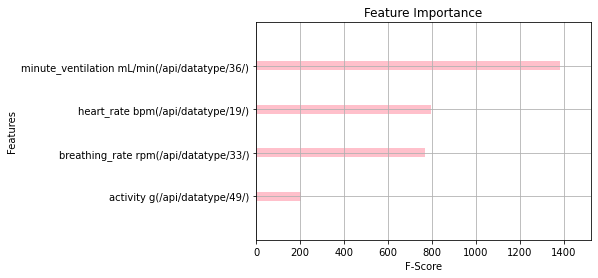

In [22]:
import pandas as pd
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Rename columns to ensure they do not contain special characters
concatenated_df.columns = [col.replace("[", "").replace("]", "").replace("<", "").replace(">", "") for col in concatenated_df.columns]

# Exclude the first and last columns
X = concatenated_df.iloc[:, 1:-1]
y = concatenated_df["Stress_Score"]

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build an XGBoost classification model
model = XGBClassifier()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# plt.figure(figsize=(10, 6))
plot_importance(model, importance_type='weight', show_values=False, max_num_features=10, color='pink')  # Adjust max_num_features as needed and set color to pink
plt.title("Feature Importance")
plt.xlabel("F-Score")
plt.ylabel("Features")
plt.show()


XGBoost Accuracy: 82.45%
Random Forest Accuracy: 91.96%
Gradient Boosting Accuracy: 70.23%
SVM Accuracy: 55.35%
KNN Accuracy: 82.41%
Logistic Regression Accuracy: 47.48%
Decision Tree Accuracy: 89.91%
Naive Bayes Accuracy: 56.87%
Neural Network Accuracy: 50.31%


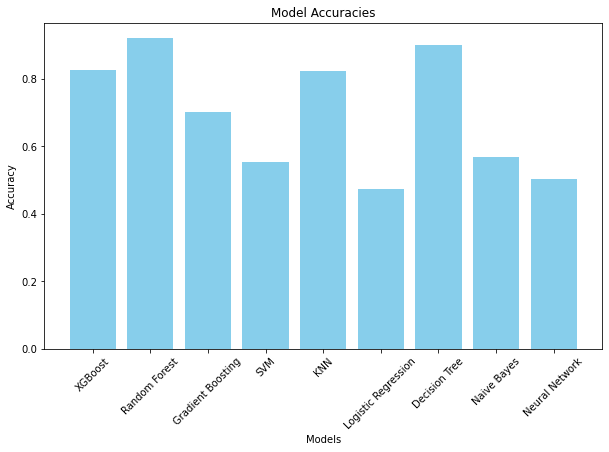

In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Rename columns to ensure they do not contain special characters
concatenated_df.columns = [col.replace("[", "").replace("]", "").replace("<", "").replace(">", "") for col in concatenated_df.columns]

# Exclude the first and last columns
X = concatenated_df.iloc[:, 1:-1]
y = concatenated_df["Stress_Score"]

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a list of models
models = [
    ("XGBoost", XGBClassifier()),
    ("Random Forest", RandomForestClassifier()),
    ("Gradient Boosting", GradientBoostingClassifier()),
    ("SVM", SVC()),
    ("KNN", KNeighborsClassifier()),
    ("Logistic Regression", LogisticRegression()),
    ("Decision Tree", DecisionTreeClassifier()),
    ("Naive Bayes", GaussianNB()),
    ("Neural Network", MLPClassifier()),
]

# Dictionary to store model accuracies
model_accuracies = {}

# Iterate over models, train, and evaluate each one
for model_name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    model_accuracies[model_name] = accuracy

# Print model accuracies
for model_name, accuracy in model_accuracies.items():
    print(f"{model_name} Accuracy: {accuracy * 100:.2f}%")

# Bar plot for model accuracies
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracies')
plt.xticks(rotation=45)
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Assuming you have already loaded your data into concatenated_df

# Rename columns to ensure they do not contain special characters
concatenated_df.columns = [col.replace("[", "").replace("]", "").replace("<", "").replace(">", "") for col in concatenated_df.columns]

# Exclude the first and last columns
X = concatenated_df.iloc[:, 1:-1]
y = concatenated_df["Stress_Score"]

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a list of models with their respective hyperparameters for grid search
models = [
    ("XGBoost", XGBClassifier(), {'n_estimators': [100, 200, 300]}),
    ("Random Forest", RandomForestClassifier(), {'n_estimators': [100, 200, 300]}),
    ("Gradient Boosting", GradientBoostingClassifier(), {'n_estimators': [100, 200, 300]}),
    ("SVM", SVC(), {'C': [1, 10, 100], 'kernel': ['linear', 'rbf']}),
    ("KNN", KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    ("Logistic Regression", LogisticRegression(), {'C': [0.1, 1, 10]}),
    ("Decision Tree", DecisionTreeClassifier(), {'max_depth': [None, 10, 20]}),
    ("Naive Bayes", GaussianNB(), {}),
    ("Neural Network", MLPClassifier(), {'hidden_layer_sizes': [(50,), (100,), (150,)], 'max_iter': [200, 300]}),
]

# Dictionary to store best model instances
best_models = {}

# Iterate over models, perform grid search, train, and evaluate each one
for model_name, model, param_grid in models:
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=5)
    grid_search.fit(X_train, y_train)
    
    # Get the best model instance from grid search
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    
    # Make predictions on the test data
    y_pred = best_model.predict(X_test)
    
    # Calculate and store accuracy for this model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Best Parameters: {grid_search.best_params_}")
    print(f"{model_name} Accuracy: {accuracy * 100:.2f}%")
    print()

# Bar plot for model accuracies
plt.figure(figsize=(10, 6))
plt.bar(best_models.keys(), [accuracy_score(y_test, best_models[model].predict(X_test)) * 100 for model in best_models], color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracies (Grid Search Tuned)')
plt.xticks(rotation=45)
plt.show()


XGBoost Best Parameters: {'n_estimators': 300}
XGBoost Accuracy: 87.54%

Random Forest Best Parameters: {'n_estimators': 100}
Random Forest Accuracy: 92.29%

Gradient Boosting Best Parameters: {'n_estimators': 300}
Gradient Boosting Accuracy: 75.56%



In [58]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

concatenated_df.columns = [col.replace("[", "").replace("]", "").replace("<", "").replace(">", "") for col in concatenated_df.columns]
# Extract "Activity Level" as predictor and "Stress_Score" as target variable
X = concatenated_df["activity g(/api/datatype/49/)"].values.reshape(-1, 1)  # Reshape to 2D array
y = concatenated_df["Stress_Score"]

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build an XGBoost classification model
model = XGBClassifier()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 50.43%


In [64]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Assuming you have already loaded your data into concatenated_df

concatenated_df.columns = [col.replace("[", "").replace("]", "").replace("<", "").replace(">", "") for col in concatenated_df.columns]

# Extract "Activity Level" as predictor and "Stress_Score" as target variable
X = concatenated_df["activity g(/api/datatype/49/)"].values.reshape(-1, 1)  # Reshape to 2D array
y = concatenated_df["Stress_Score"]

# Initialize 5-fold Cross-Validation
kf = KFold(n_splits=100, shuffle=True, random_state=42)

# Initialize an empty list to store accuracy scores
accuracy_scores = []

# Perform 5-fold Cross-Validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Build an XGBoost classification model
    model = XGBClassifier()
    
    # Train the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = model.predict(X_test)
    
    # Calculate and store accuracy for this fold
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

# Calculate the average accuracy across all folds
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)
print(f"Average Model Accuracy: {average_accuracy * 100:.2f}%")


Average Model Accuracy: 52.07%


In [67]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Assuming you have already loaded your data into concatenated_df

concatenated_df.columns = [col.replace("[", "").replace("]", "").replace("<", "").replace(">", "") for col in concatenated_df.columns]

# Extract "Activity Level" as predictor and "Stress_Score" as target variable
X = concatenated_df["activity g(/api/datatype/49/)"].values.reshape(-1, 1)  # Reshape to 2D array
y = concatenated_df["Stress_Score"]

# Initialize 5-fold Cross-Validation
kf = KFold(n_splits=100, shuffle=True, random_state=42)

# Initialize an empty list to store accuracy scores
accuracy_scores = []

# Perform 5-fold Cross-Validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Build a Random Forest classification model
    model = RandomForestClassifier(random_state=42)
    
    # Train the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = model.predict(X_test)
    
    # Calculate and store accuracy for this fold
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

# Calculate the average accuracy across all folds
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)
print(f"Average Model Accuracy: {average_accuracy * 100:.2f}%")


Average Model Accuracy: 52.06%


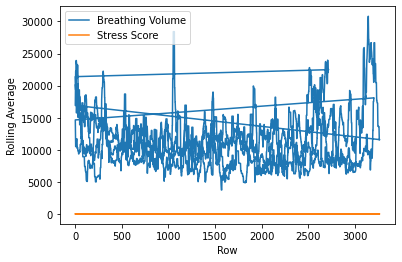

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate rolling averages 
roll_vent = concatenated_df['minute_ventilation mL/min(/api/datatype/36/)'].rolling(2).mean()
roll_stress = concatenated_df['Stress_Score'].rolling(2).mean()

# Plot
plt.plot(roll_vent, label='Breathing Volume')
plt.plot(roll_stress, label='Stress Score')
plt.xlabel('Row')
plt.ylabel('Rolling Average')
plt.legend()

plt.show()

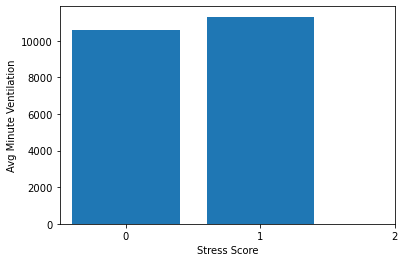

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter dataframe by stress score 
df_0 = concatenated_df[concatenated_df['Stress_Score'] == 0]
df_1 = concatenated_df[concatenated_df['Stress_Score'] == 1] 
df_2 = concatenated_df[concatenated_df['Stress_Score'] == 2]

# Calculate average ventilation for each
vent_0 = df_0['minute_ventilation mL/min(/api/datatype/36/)'].mean()
vent_1 = df_1['minute_ventilation mL/min(/api/datatype/36/)'].mean()
vent_2 = df_2['minute_ventilation mL/min(/api/datatype/36/)'].mean()

# Plot bar chart
# Plot bar chart
plt.bar([0, 1, 2], [vent_0, vent_1, vent_2]) 

# Set x-ticks from 0 to 2 stepped by 1
plt.xticks(ticks=range(0, 3))

plt.xlabel('Stress Score')
plt.ylabel('Avg Minute Ventilation')

plt.show()

plt.show()

In [27]:
print(len(concatenated_df['minute_ventilation mL/min(/api/datatype/36/)']), len(concatenated_df['Stress_Score']))

12195 12195


In [31]:
print(concatenated_df.columns)

Index(['time s/256', 'breathing_rate rpm(/api/datatype/33/)',
       'minute_ventilation mL/min(/api/datatype/36/)',
       'minute_ventilation_adjusted mL/min(/api/datatype/38/)',
       'activity g(/api/datatype/49/)', 'heart_rate bpm(/api/datatype/19/)',
       'Stress_Score'],
      dtype='object')


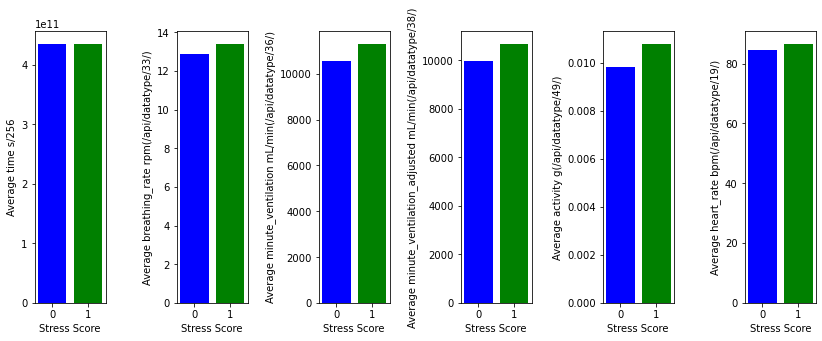

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

features = concatenated_df.columns.drop('Stress_Score')

fig, axs = plt.subplots(ncols=len(features), figsize=(14,5), gridspec_kw={'wspace': 1}) 

cmap = ['b','g','r']

for i, feature in enumerate(features):

  df_0 = concatenated_df[concatenated_df['Stress_Score'] == 0]
  df_1 = concatenated_df[concatenated_df['Stress_Score'] == 1]
  df_2 = concatenated_df[concatenated_df['Stress_Score'] == 2]

  f0 = df_0[feature].mean() 
  f1 = df_1[feature].mean()
  f2 = df_2[feature].mean()

  axs[i].bar([0,1,2], [f0, f1, f2], color=cmap)
  axs[i].set_xlabel('Stress Score')
  axs[i].set_ylabel('Average '+ feature)


plt.show()

In [38]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Calculate VIF for all columns except first and last
vif = [variance_inflation_factor(concatenated_df.values, i) 
       for i in range(0, len(concatenated_df.columns))]
print(concatenated_df.columns)
print(vif)

Index(['time s/256', 'breathing_rate rpm(/api/datatype/33/)',
       'minute_ventilation mL/min(/api/datatype/36/)',
       'minute_ventilation_adjusted mL/min(/api/datatype/38/)',
       'activity g(/api/datatype/49/)', 'heart_rate bpm(/api/datatype/19/)',
       'Stress_Score'],
      dtype='object')
[136.26607209892248, 1.2646179093921526, inf, inf, 1.2732393074377992, 1.0994261979790525, 1.0282394801200152]


/Users/latherialcalbert/opt/anaconda3/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


In [40]:
vif = [variance_inflation_factor(concatenated_df.iloc[:, [2,4]].values, i)  
       for i in range(2)]

print(vif)

[1.1375204321939956, 1.1375204321939958]


In [56]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

# Ventilation model
vent_model = XGBClassifier() 
vent_model.fit(X_train[['minute_ventilation mL/min(/api/datatype/36/)']], y_train)

# Make predictions
vent_train_pred = vent_model.predict(X_train[['minute_ventilation mL/min(/api/datatype/36/)']])
vent_test_pred = vent_model.predict(X_test[['minute_ventilation mL/min(/api/datatype/36/)']])

# Add ventilation prediction to training data
X_train['vent_pred'] = vent_train_pred  

# Stacked model 
stacked_model = XGBClassifier()
stacked_model.fit(X_train, y_train)

# Add ventilation prediction to test data
X_test['vent_pred'] = vent_test_pred

# Predict on stacked model
y_pred = stacked_model.predict(X_test)

# Calculate accuracy
vent_acc = accuracy_score(y_test, vent_test_pred)
stacked_acc = accuracy_score(y_test, y_pred)

print("Ventilation Model Accuracy:", vent_acc)
print("Stacked Model Accuracy:", stacked_acc)

Ventilation Model Accuracy: 0.6318163181631816
Stacked Model Accuracy: 1.0


In [57]:
print(concatenated_df.head)

<bound method NDFrame.head of         time s/256  breathing_rate rpm(/api/datatype/33/)  \
0     4.345952e+11                                   11.0   
1     4.345952e+11                                   11.0   
2     4.345952e+11                                   11.0   
3     4.345952e+11                                   11.0   
4     4.345952e+11                                   10.0   
...            ...                                    ...   
3001  4.348614e+11                                   19.0   
3002  4.348614e+11                                   19.0   
3003  4.348614e+11                                   19.0   
3004  4.348614e+11                                   19.0   
3005  4.348614e+11                                   19.0   

      minute_ventilation mL/min(/api/datatype/36/)  \
0                                         20796.48   
1                                         19375.52   
2                                         19375.52   
3                    

In [45]:
# Accuracy metrics
from sklearn.metrics import mean_absolute_error, r2_score

# Ventilation model accuracy
vent_mae = mean_absolute_error(y_test, vent_test_pred)
vent_r2 = r2_score(y_test, vent_test_pred)

print("Ventilation Model MAE:", vent_mae) 
print("Ventilation Model R-squared:", vent_r2)

# Stacked model accuracy
stacked_mae = mean_absolute_error(y_test, y_pred)
stacked_r2 = r2_score(y_test, y_pred)

print("Stacked Model MAE:", stacked_mae)
print("Stacked Model R-squared:", stacked_r2)

Ventilation Model MAE: 0.4341694224181357
Ventilation Model R-squared: 0.0957870578868637
Stacked Model MAE: 0.41744698184869217
Stacked Model R-squared: 0.10693260694066575
